In [188]:
# Import necessary libraries.
import json
import networkx as nx
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pickle
from PIL import Image
import itertools

In [234]:
# Make a NetworkX graph from a node-link JSON file. Also extract the floorplan base image and resize it.
def MakeGraph2(plan,Out=True):
    with open(f'Data 2/{plan}/graph_output.json', 'r') as f:
        data = json.load(f)

    # Make the graph
    G = json_graph.node_link_graph(data, edges='links')
    
    # Add the Outside as a node, connecting to exterior doors, if desired.
    if Out:
        ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
        G.add_node('Outside', room_id='-1', room_name='Outside', room_size=1, position=(0,0))
        G.add_edges_from([(Door, 'Outside') for Door in ExDoors], connection='Outside')

    return G

# Get each folder name for the data.
def graph_generator():
    '''Yield all graphs and their corresponding images from the data directory.'''
    subfolders= [f.path.split('/')[-1] for f in os.scandir('Data 2/') if f.is_dir()]
    for plan in sorted(subfolders):
        G = MakeGraph2(plan,False)
        GOut = MakeGraph2(plan)
        yield plan, G, GOut

# Plot the graph.
def GraphPlot(G, plan, Save=False): 
    ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
    pos = {node: tuple(data['position']) for node, data in G.nodes(data=True)}
    NodeColours = ['lime' if node=='Outside' else 'magenta' if node in ExDoors else 'tab:red' if dat['room_name']=='door' else 'tab:blue' for node,dat in G.nodes(data=True)]
    #EdgeColours = ['lime' if (node1=='Outside' or node2=='Outside') else 'tab:red' if ('door' in node2 and 'door' not in node1) else 'tab:blue' for node1,node2,dat in G.edges(data=True)]
    EdgeColours = ['lime' if dat['connection']=='Outside' else 'tab:red' if dat['connection']=='door' else 'magenta' if dat['connection']=='exit' else 'tab:blue' for _,_,dat in G.edges(data=True)]
        
    plt.figure(figsize=(8,8))

    try:
        image = Image.open(f'Data 2/{plan}/output/graph_on_input.png')
    
        # Obtain the floorplan image and resize it as necessary.
        with open(f'Data 2/{plan}/output/model_processed.pkl', 'rb') as f:
            room_masks = pickle.load(f)
        first_key = next(iter(room_masks))
        mask_shape = room_masks[first_key][0].shape
        target_h, target_w = mask_shape[:2]
        image = image.resize( (target_w, target_h))
        plt.imshow(image)
    except:
        pass
        
    nx.draw_networkx(G, pos=pos, with_labels=True, node_size=300, node_color=NodeColours, edge_color=EdgeColours, width=3, font_size=6)
    
    # Node legend
    node_handles = [
        mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None', markersize=10, label='Door'),
        mlines.Line2D([], [], color='magenta', marker='o', linestyle='None', markersize=10, label='Exit Door'),
        mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None', markersize=10, label='Room'),
        mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=10, label='Outside'),
    ]
    # Edge legend
    edge_handles = [
        mlines.Line2D([], [], color='tab:red', linewidth=4, label='Door Connection'),
        mlines.Line2D([], [], color='tab:blue', linewidth=4, label='Adjacent'),
        mlines.Line2D([], [], color='lime', linewidth=4, label='Outside Connection'),
    ]
    plt.legend(handles=node_handles + edge_handles, loc='best',frameon=True)
    
    plt.axis('equal')
    if Save:
        plt.savefig(f'Data 2/{plan}/output/graph_on_input_new.png', dpi=500)
    plt.show()

# Removes adjacency connections.
def RemoveAdjacency(G):
    GDoors = G.copy()
    GDoors.remove_edges_from([[u,v] for u,v,dat in G.edges(data=True) if dat['connection']=='adjacent'])
    return GDoors

# Removes doors and replace with a 'door' edge.
def RemoveDoors(G):
    H = G.copy()
    for door in [door for door, dat in H.nodes(data=True) if 'door' in door]:
        if H.degree[door]==2:
            H.add_edge(*tuple(nx.all_neighbors(H,door)), connection='door')
            H.remove_node(door)
        elif H.degree[door]==1:
            H.remove_node(door)
    return H

# Identify rooms adjacent to the 'hallway' that you have to go through a small room to get to.
# Useful to identify potentially incorrect door placements.
def smallThroughRoom(G,plan,Ratio=1.5):
    # ratio is how much larger the room needs to be.
    
    # Remove doors and adjacency connections.
    H2 = RemoveDoors(G)
    H = RemoveAdjacency(H2)

    # Find the candidate for the hall
    Hall,deg = max(H.degree, key=lambda x: x[1])

    # Dictionary for node data.
    nodeDict = dict(H2.nodes(data=True))

    # Identify potentially incorrect door placements. Hallway needs to have degree more than 2 to count as a hallway.
    if deg>2:
        for room in [node for node in list(nx.all_neighbors(H,Hall)) if H.degree[node]>1]:
            roomSize = nodeDict[room]['room_size']
            neighboursSize = [[adjroom,nodeDict[adjroom]['room_size']] for adjroom in list(nx.all_neighbors(H,room))] # doesn't include hall (by design)
            for neighbours in neighboursSize:
                nRoom, nSize = neighbours
                if nRoom in nx.all_neighbors(H2,Hall):
                    if H2[Hall][nRoom]['connection']=='adjacent' and nSize/roomSize>Ratio:
                        print(f'{plan}: Room {nRoom} is more than {Ratio} times bigger than room {room}. Perhaps the hallway (room {Hall}) should connect to Room {nRoom} directly.')

def check_all(eps=10):
    for plan, G, GOut in graph_generator():
        H = RemoveAdjacency(GOut)

        smallThroughRoom(G,plan,Ratio=1.5)

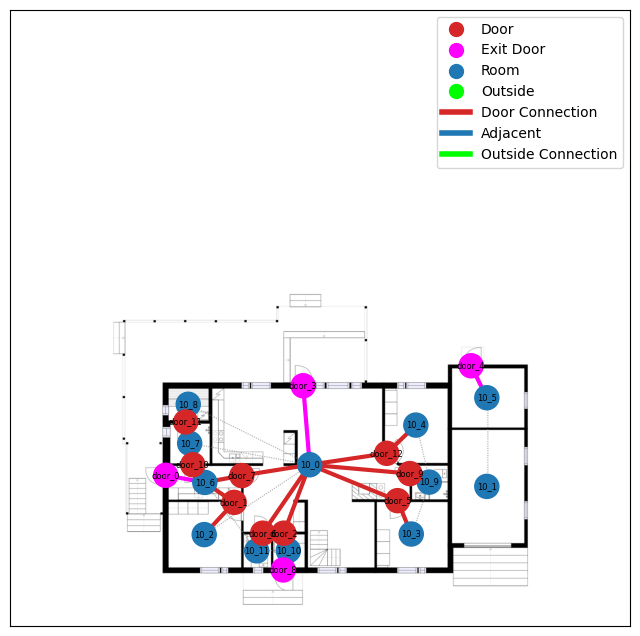

In [ ]:
# Make a specific graph from the json data.
plan = 10108
G2Out = MakeGraph2(plan,True)
G2 = MakeGraph2(plan,False)
G = RemoveAdjacency(G2)

smallThroughRoom(G2,plan)

# Plot the Graph, with the floorplan.
GraphPlot(G,plan)

In [235]:
check_all()

10108: Room 10_2 is more than 1.5 times bigger than room 10_6. Perhaps the hallway (room 10_0) should connect to Room 10_2 directly.
10143: Room 22_0 is more than 1.5 times bigger than room 4. Perhaps the hallway (room missing_room_fp_0_25) should connect to Room 22_0 directly.
10147: Room 11 is more than 1.5 times bigger than room missing_room_fp_1_14. Perhaps the hallway (room missing_room_fp_2_15) should connect to Room 11 directly.
10149: Room 4 is more than 1.5 times bigger than room 7. Perhaps the hallway (room 19) should connect to Room 4 directly.
10203: Room 1 is more than 1.5 times bigger than room 8. Perhaps the hallway (room 13_0) should connect to Room 1 directly.
10212: Room 5 is more than 1.5 times bigger than room 8. Perhaps the hallway (room 19) should connect to Room 5 directly.
10275: Room 1 is more than 1.5 times bigger than room 4. Perhaps the hallway (room 0) should connect to Room 1 directly.
10301: Room 5 is more than 1.5 times bigger than room missing_room_p_5_